In [2]:
import pickle
import pandas as pd
import numpy as np
import gc

## RF

In [3]:
filepath_base_rf = "model/debit/base_rf_ros_31_feats_20250702.pkl"
with open(filepath_base_rf, "rb") as f:
    base_rf = pickle.load(f)

## Data

In [4]:
df_final = pd.read_parquet("data/ready_to_train/df_debit_final_25_feats_20250702.parquet")

In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714734 entries, 1047361273 to 1143344726
Data columns (total 27 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   Confirmed                            714734 non-null  float64       
 1   Transaction Datetime                 714734 non-null  datetime64[ns]
 2   SumAmtL30D                           714734 non-null  float64       
 3   TxnCountL30D                         714734 non-null  float64       
 4   CountTrxTrf                          385721 non-null  float64       
 5   TotalTrxAmount10Mi                   680394 non-null  float64       
 6   TotalTrxAmountL5min                  679661 non-null  float64       
 7   TotalTrxAmount15Mi                   680838 non-null  float64       
 8   CntUniqueCardNoByMCCL30D             188090 non-null  float64       
 9   TotalTrxAmountL1D                    689679 non-null  float64 

In [14]:
2.000000e+09

2000000000.0

In [12]:
df_final.TransactionAmount.describe()

count    6.842740e+05
mean     2.091307e+07
std      5.958698e+07
min      0.000000e+00
25%      7.250000e+04
50%      9.840000e+05
75%      1.000001e+07
max      2.000000e+09
Name: TransactionAmount, dtype: float64

In [5]:
# setup pipeline
from src.model_pipeline import ModelPipeline

pipeline_rf = ModelPipeline(model_type="random_forest", random_state=42)

split_date = '2025-05-01'
df_splits = pipeline_rf.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [6]:
# prepare OOS data
target_col = "Confirmed"
X, y = pipeline_rf.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'HighRiskCustomer': ['0', 'N', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '7', '9', '__missing__']
CategoryManager fitting complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 

In [7]:
X_oos, y_oos = pipeline_rf.prepare_data(
    df=df_splits["df_test"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 'TimeFirstTxnToCurrentMCC', 'AvgTimeFirstTxnToCurrentMCCL30D', 'AvgTrnxHourL15min', 'CntUniqueCardNoByMCCL15min']
Identified categorical columns (encoded): []
Transforming data using NumericalImputer...
  Imputed column 'SumA

# Binning Proba Analysis

In [7]:
from src.utils import plot_confusion_matrix, generate_pred_df, compute_bin_aggregates

In [8]:
df_pred = generate_pred_df(
    X=X_oos,
    y=y_oos,
    clf=base_rf,
    amount_col='TransactionAmount',
    bin_on='pbad',
    increment_bin_rate=0.025,
    bins=None
)

In [9]:
df_agg = compute_bin_aggregates(df_pred)

C:\Users\Administrator\BDI-predator\ml-fraud\src\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = pred_df.groupby("bin").agg(agg_cols)


In [11]:
df_agg.to_csv("data/result/debit_rf_bin_proba_analysis_20250702.csv")

In [12]:
y_oos_prob = base_rf.predict_proba(X_oos)[:, 1]
df_pred = X_oos.join(y_oos)
df_pred = df_pred[['Confirmed']]

In [13]:
df_pred['P_Bad'] = y_oos_prob
df_pred['Confirmed'] = df_pred['Confirmed'].astype(int)

In [14]:
df_pred.to_csv("data/result/DEBIT_df_pred_oos_rf_20250703.csv")

# Importance Feat

In [40]:
df_importance = pd.DataFrame(
    {"feature": X.columns, "importance": base_rf.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

In [41]:
df_importance

,feature,importance
0,SumAmtL30D,0.121772
1,TxnCountL30D,0.106553
2,CountTrxTrf,0.084835
3,TotalTrxAmount10Mi,0.069249
4,CntUniqueCardNoByMCCL30D,0.064164
5,TotalTrxAmount15Mi,0.063139
6,TotalTrxAmountL1D,0.052043
7,TotalTrxAmountL5min,0.051774
8,CustomerAge,0.047518
9,TransactionAmount,0.047406


In [18]:
df_importance.to_csv("data/result/debit_rf_importance_20250624.csv", index=False)

# FP Reduction

In [8]:
from src.utils import plot_confusion_matrix

In [9]:
df_dc_rules = pd.read_parquet("data/others/debit_card_triggered_rules.parquet")

In [10]:
df_dc_rules_join = df_dc_rules.merge(X_oos['TransactionAmount'], how='left', left_on='Transaction Serial No', right_index=True)

In [16]:
# fraud rules
print("actual fraud amount from Rules that prevented:", 
      df_dc_rules_join[(df_dc_rules_join['IsTriggeredRules'] == 1) & (df_dc_rules_join['Confirmed'] == 1)]['TransactionAmount'].sum())
print("false positive amount from Rules that loss:",
      df_dc_rules_join[(df_dc_rules_join['IsTriggeredRules'] == 1) & (df_dc_rules_join['Confirmed'] == 0)]['TransactionAmount'].sum())

actual fraud amount from Rules that prevented: 0.0
false positive amount from Rules that loss: 80006676099.2


In [11]:
X_oos_selected = X_oos[X_oos.index.isin(df_dc_rules['Transaction Serial No'])]
y_oos_selected = y_oos[y_oos.index.isin(df_dc_rules['Transaction Serial No'])]

In [12]:
y_oos_selected_proba = base_rf.predict_proba(X_oos_selected)[:, 1]

In [17]:
df_dc_rules_join.set_index("Transaction Serial No", drop=True, inplace=True)

In [19]:
df_oos_selected = X_oos_selected[['TransactionAmount']].join(y_oos_selected).copy()
df_oos_selected['MLScore'] = y_oos_selected_proba
df_oos_selected['IsTriggeredRules'] = df_dc_rules_join['IsTriggeredRules']

In [20]:
# ML
print("actual fraud amount from Rules that prevented:", 
      df_oos_selected[(df_oos_selected['MLScore'] > 0.69) & (df_oos_selected['Confirmed'] == 1)]['TransactionAmount'].sum())
print("false positive amount from Rules that loss:",
      df_oos_selected[(df_oos_selected['MLScore'] > 0.69) & (df_oos_selected['Confirmed'] == 0)]['TransactionAmount'].sum())

actual fraud amount from Rules that prevented: 1528300000.0
false positive amount from Rules that loss: 27900194967.489998


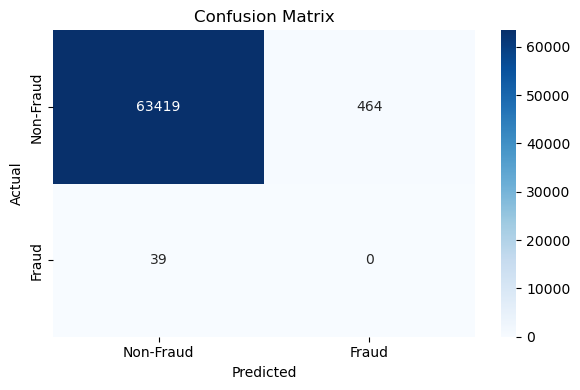

Recall/True Positive Rate: The model got 0.0% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 0.0% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.73% of the records from total to the Alert rate


In [20]:
# threshold_oos = 0.69
plot_confusion_matrix(
    df_oos_selected['Confirmed'],
    df_oos_selected['IsTriggeredRules']
)

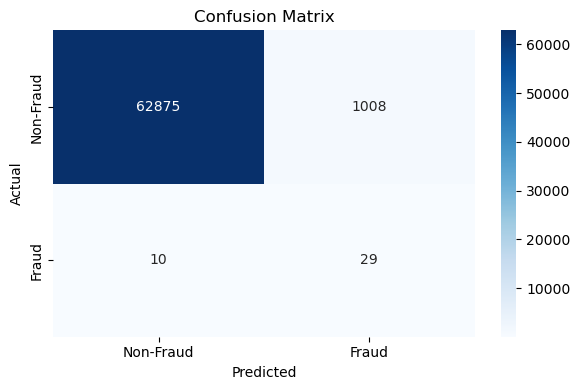

Recall/True Positive Rate: The model got 74.36% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 2.8% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 1.62% of the records from total to the Alert rate


In [47]:
plot_confusion_matrix(
    df_oos_selected['Confirmed'],
    df_oos_selected['MLScore'],
    0.45
)

In [49]:
df_oos_selected['MLScore > 0.45'] = df_oos_selected['MLScore'] > 0.45

In [48]:
(39-10)/39

0.7435897435897436

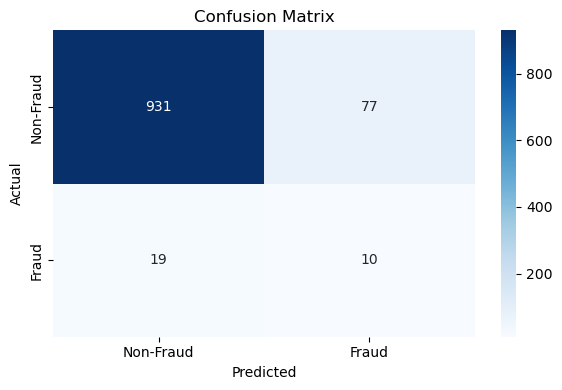

Recall/True Positive Rate: The model got 34.48% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 11.49% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 8.39% of the records from total to the Alert rate


In [59]:
plot_confusion_matrix(
    df_oos_selected[df_oos_selected['MLScore > 0.45'] == True]['Confirmed'],
    df_oos_selected[df_oos_selected['MLScore > 0.45'] == True]['MLScore'],
    0.91
)

In [60]:
df_oos_selected[(df_oos_selected['MLScore'] > 0.91) & (df_oos_selected['Confirmed'] == True)]['TransactionAmount'].sum()

441700000.0

In [61]:
df_oos_selected[(df_oos_selected['MLScore'] > 0.91) & (df_oos_selected['Confirmed'] == False)]['TransactionAmount'].sum()

7248144228.889999

In [35]:
y_oos_selected.value_counts(normalize=True)

Confirmed
0.0    0.99939
1.0    0.00061
Name: proportion, dtype: float64

In [37]:
df_pred_selected = generate_pred_df(
    X=X_oos_selected,
    y=y_oos_selected,
    clf=base_rf,
    amount_col='TransactionAmount',
    bin_on='pbad',
    increment_bin_rate=0.025,
    bins=None
)

In [38]:
df_agg_selected = compute_bin_aggregates(df_pred_selected)

C:\Users\Administrator\BDI-predator\ml-fraud\src\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = pred_df.groupby("bin").agg(agg_cols)


In [39]:
df_agg_selected.to_csv("data/result/debit_rf_bin_proba_analysis_20250708.csv")

In [45]:
X_oos_selected['Proba'] = y_oos_selected_proba

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_5360\1827141736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_oos_selected['Proba'] = y_oos_selected_proba


In [46]:
merged_df = pd.merge(
    df_dc_rules[[
        'Transaction Serial No',
        'Transaction Datetime',
        'Triggered_Rules',
        'Channel',
        'Confirmed',
        'IsTriggeredRules'
    ]],
    X_oos_selected['Proba'],
    left_on='Transaction Serial No',
    right_index=True
)

In [47]:
merged_df.to_csv("data/others/debit_card_rules_ml_20250709.csv", index=False)